In [1]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv(r"../dataset/Sub_Division_IMD_2017.csv")

# Display first 5 rows
df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [2]:
# Check dataset shape
df.shape

(4188, 19)

In [3]:
# Check column names
df.columns

Index(['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS',
       'OND'],
      dtype='object')

In [4]:
# Basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4188 non-null   object 
 1   YEAR         4188 non-null   int64  
 2   JAN          4184 non-null   float64
 3   FEB          4185 non-null   float64
 4   MAR          4182 non-null   float64
 5   APR          4184 non-null   float64
 6   MAY          4185 non-null   float64
 7   JUN          4183 non-null   float64
 8   JUL          4181 non-null   float64
 9   AUG          4184 non-null   float64
 10  SEP          4182 non-null   float64
 11  OCT          4181 non-null   float64
 12  NOV          4177 non-null   float64
 13  DEC          4178 non-null   float64
 14  ANNUAL       4162 non-null   float64
 15  JF           4182 non-null   float64
 16  MAM          4179 non-null   float64
 17  JJAS         4178 non-null   float64
 18  OND          4175 non-null   float64
dtypes: flo

In [5]:
df.isnull().sum()

SUBDIVISION     0
YEAR            0
JAN             4
FEB             3
MAR             6
APR             4
MAY             3
JUN             5
JUL             7
AUG             4
SEP             6
OCT             7
NOV            11
DEC            10
ANNUAL         26
JF              6
MAM             9
JJAS           10
OND            13
dtype: int64

In [6]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [7]:
df.isnull().sum()

SUBDIVISION    0
YEAR           0
JAN            0
FEB            0
MAR            0
APR            0
MAY            0
JUN            0
JUL            0
AUG            0
SEP            0
OCT            0
NOV            0
DEC            0
ANNUAL         0
JF             0
MAM            0
JJAS           0
OND            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Missing values were identified in monthly and seasonal rainfall attributes. Since the percentage of missing data was very low, numerical missing values were replaced using mean imputation. Duplicate records were checked and removed if present to ensure data quality and consistency.

In [ ]:
#Distribution of Annual Rainfall

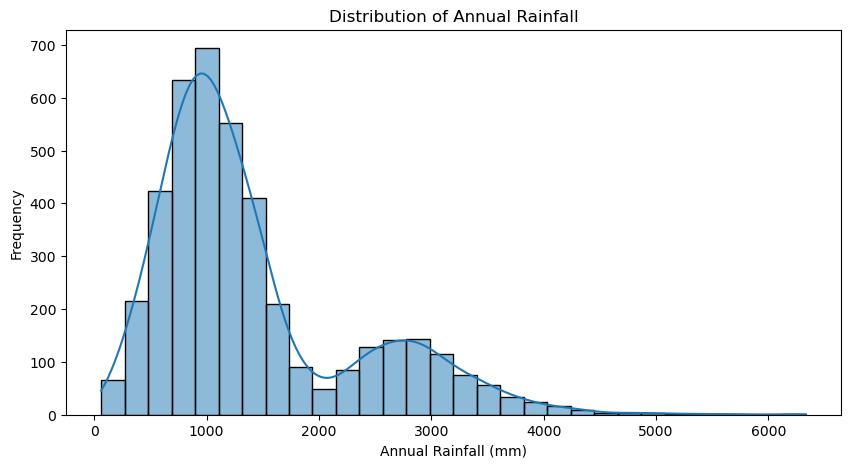

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df['ANNUAL'], bins=30, kde=True)

plt.title("Distribution of Annual Rainfall")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#Boxplot of Annual Rainfall

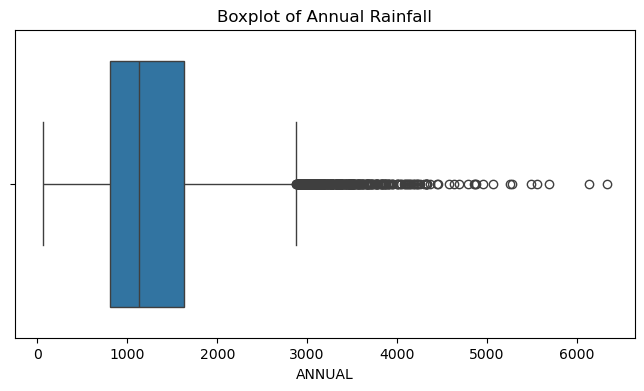

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['ANNUAL'])

plt.title("Boxplot of Annual Rainfall")

plt.show()

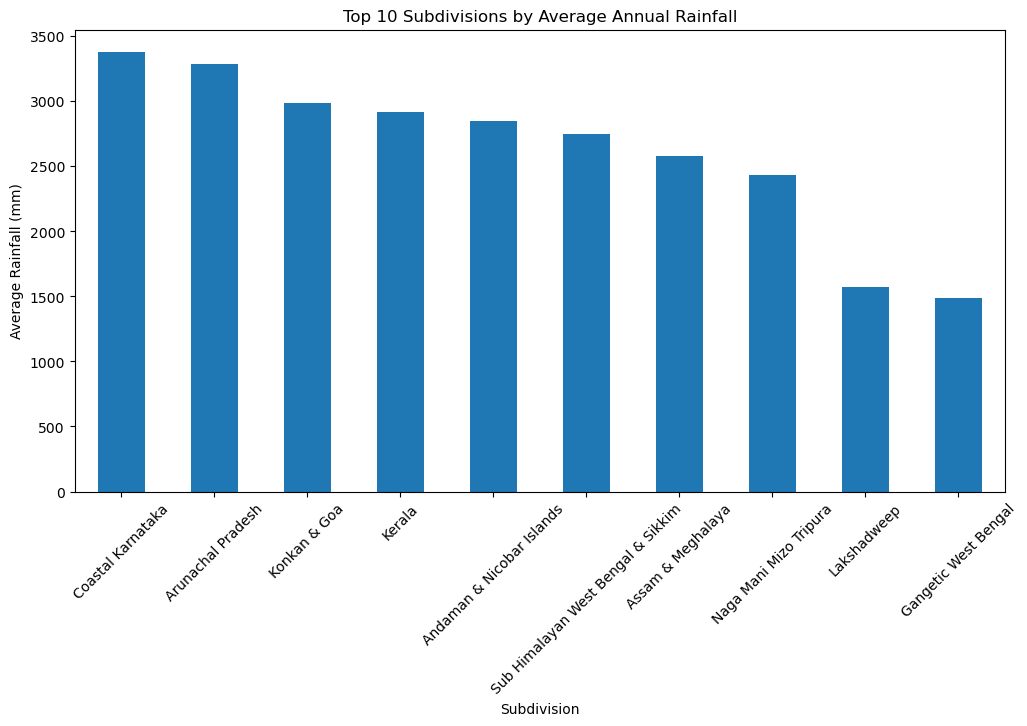

In [12]:
top_rainfall = df.groupby('SUBDIVISION')['ANNUAL'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

top_rainfall.head(10).plot(kind='bar')

plt.title("Top 10 Subdivisions by Average Annual Rainfall")
plt.xlabel("Subdivision")
plt.ylabel("Average Rainfall (mm)")

plt.xticks(rotation=45)
plt.show()

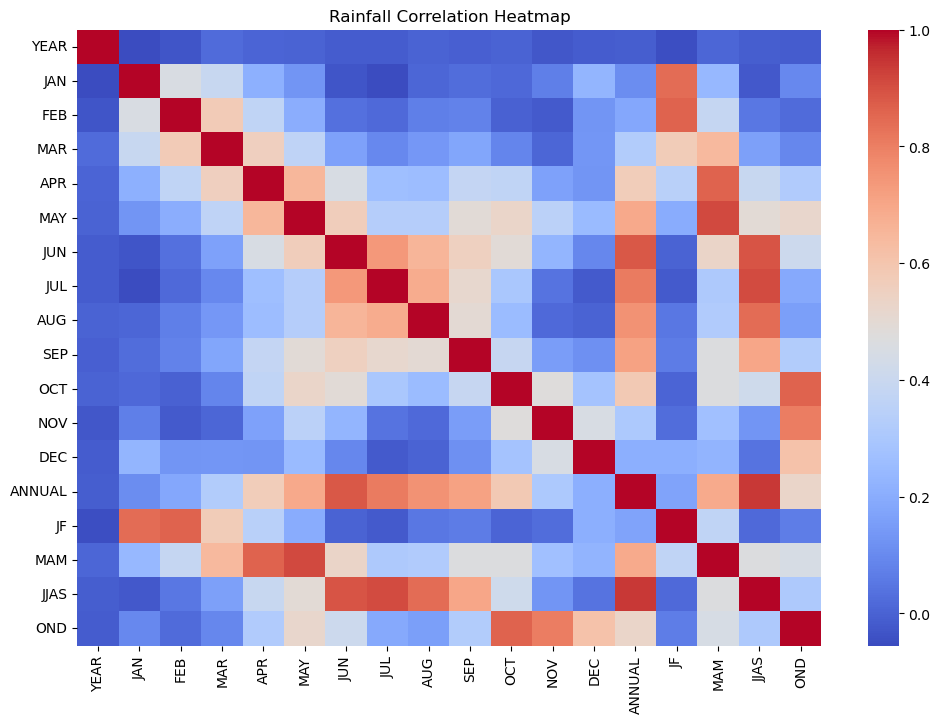

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title("Rainfall Correlation Heatmap")

plt.show()

Distribution Plot

Annual rainfall is right-skewed.
Most observations lie between 500–2000 mm.
Few regions receive extremely high rainfall (>4000 mm).

Boxplot

Several outliers exist.
These are not errors; they represent high-rainfall regions like Meghalaya and Western Ghats.
Do not remove these outliers because they are real climatic observations.

Top 10 Rainfall Regions

Coastal Karnataka, Konkan & Goa, Kerala, Assam & Meghalaya are among the highest rainfall regions.
Confirms geographical rainfall patterns in India.

Correlation Heatmap

JJAS (Southwest Monsoon season) has the strongest relationship with Annual Rainfall.
This indicates monsoon rainfall is the major contributor to India's annual rainfall.

In [14]:
yearly_rainfall = df.groupby('YEAR')['ANNUAL'].mean().reset_index()

yearly_rainfall.head()

,YEAR,ANNUAL
0,1901,1284.214286
1,1902,1337.302857
2,1903,1400.181406
3,1904,1236.771429
4,1905,1186.177143


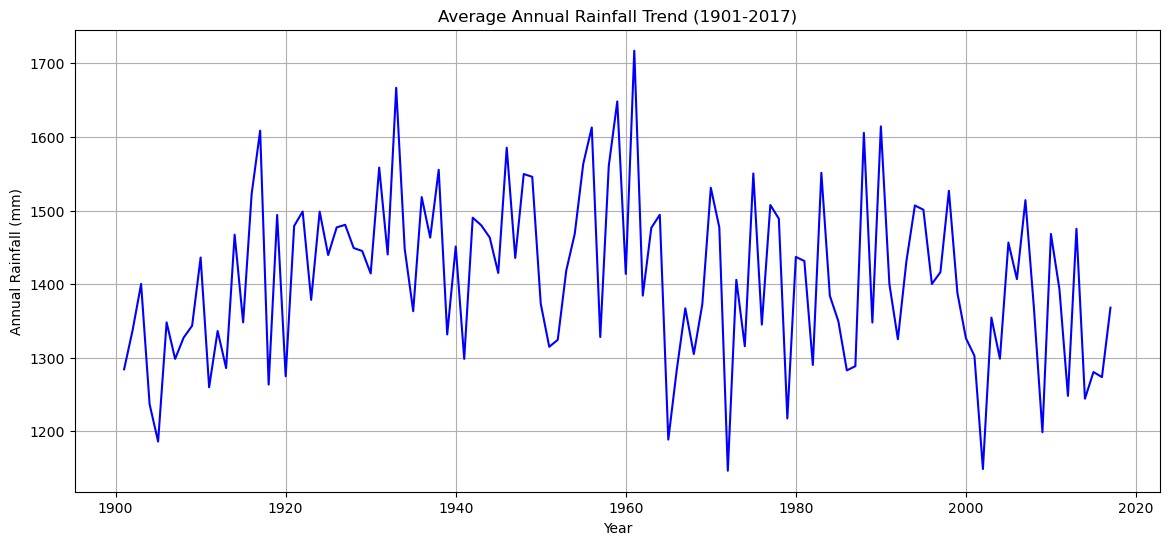

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_rainfall['YEAR'],
    yearly_rainfall['ANNUAL'],
    color='blue'
)

plt.title("Average Annual Rainfall Trend (1901-2017)")
plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")

plt.grid(True)

plt.show()

In [16]:
yearly_rainfall['Moving_Avg_5'] = (
    yearly_rainfall['ANNUAL']
    .rolling(window=5)
    .mean()
)

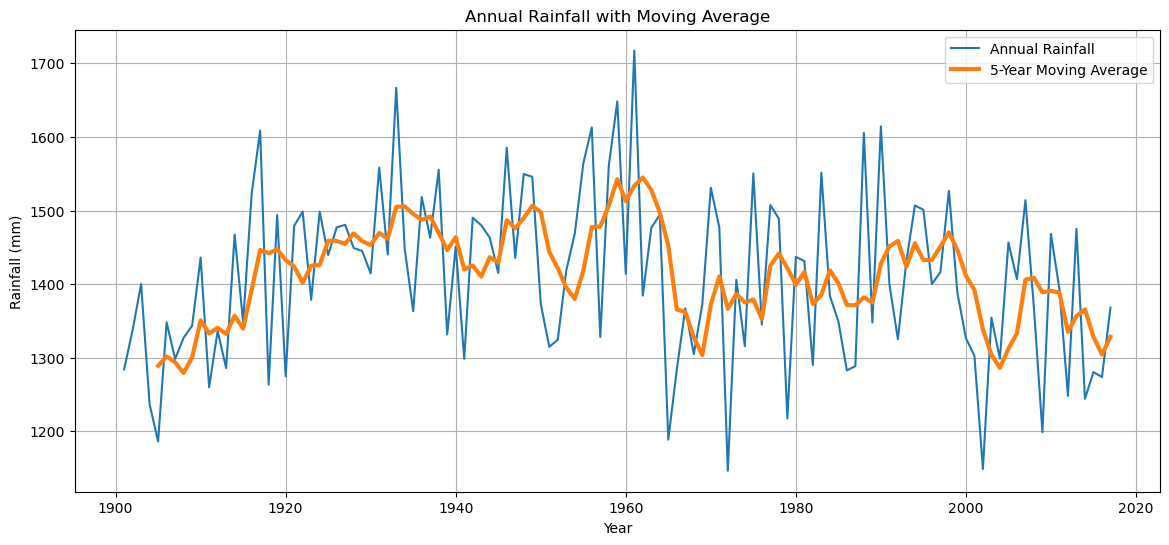

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_rainfall['YEAR'],
    yearly_rainfall['ANNUAL'],
    label='Annual Rainfall'
)

plt.plot(
    yearly_rainfall['YEAR'],
    yearly_rainfall['Moving_Avg_5'],
    linewidth=3,
    label='5-Year Moving Average'
)

plt.title("Annual Rainfall with Moving Average")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(yearly_rainfall['ANNUAL'])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -4.4734249670476185
p-value : 0.00021956358556414737


In [19]:
q1 = df['ANNUAL'].quantile(0.25)
q3 = df['ANNUAL'].quantile(0.75)

def classify_rainfall(x):
    if x < q1:
        return "Drought"
    elif x > q3:
        return "Heavy Rainfall"
    else:
        return "Normal"

df['Rainfall_Category'] = df['ANNUAL'].apply(classify_rainfall)

df['Rainfall_Category'].value_counts()

Rainfall_Category
Normal            2094
Heavy Rainfall    1047
Drought           1047
Name: count, dtype: int64

In [77]:
df.to_csv(
    "cleaned_rainfall_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


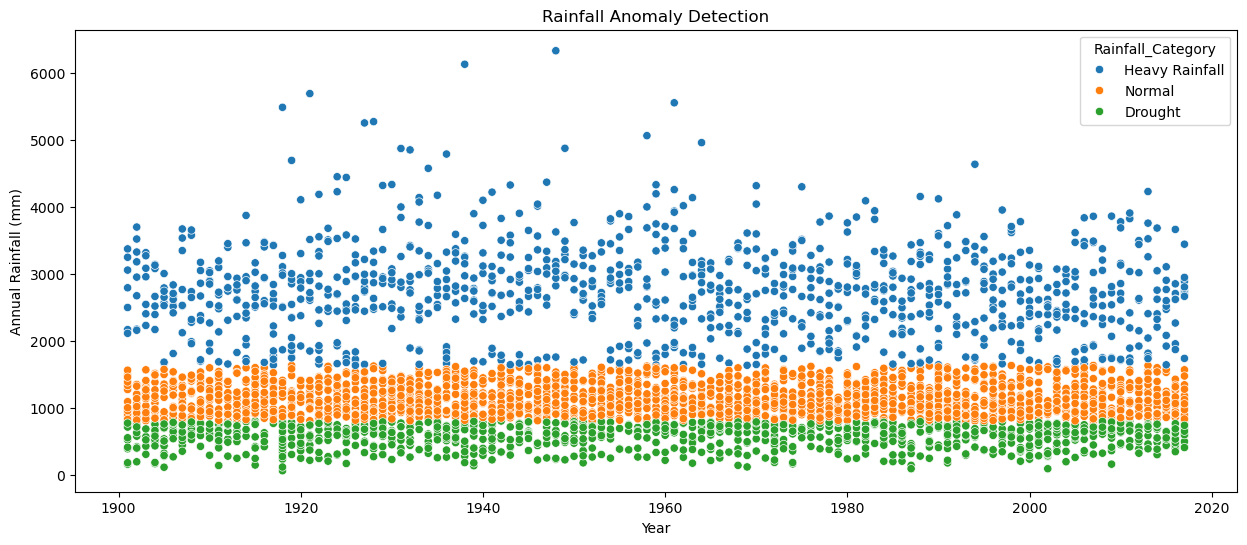

In [20]:
plt.figure(figsize=(15,6))

sns.scatterplot(
    data=df,
    x='YEAR',
    y='ANNUAL',
    hue='Rainfall_Category'
)

plt.title("Rainfall Anomaly Detection")
plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.show()

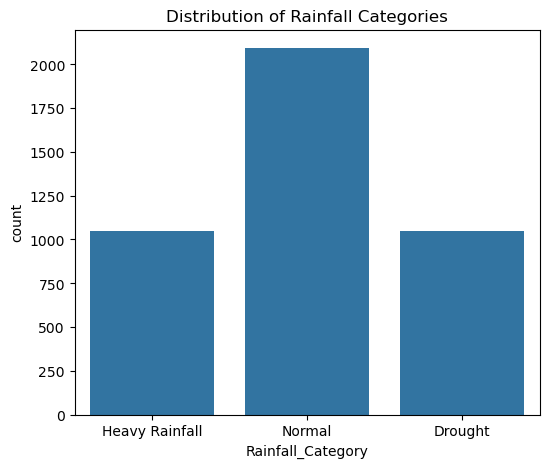

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Rainfall_Category'
)

plt.title("Distribution of Rainfall Categories")

plt.show()

In [23]:
#Feature Engineering for Accurate ML Model
#sort the dataset
df = df.sort_values(by=['SUBDIVISION', 'YEAR'])

In [24]:
df['Lag_1'] = df.groupby('SUBDIVISION')['ANNUAL'].shift(1)
df['Lag_2'] = df.groupby('SUBDIVISION')['ANNUAL'].shift(2)
df['Lag_3'] = df.groupby('SUBDIVISION')['ANNUAL'].shift(3)

In [25]:
df['Rolling_3'] = df.groupby('SUBDIVISION')['ANNUAL'].shift(1).rolling(window=3).mean()
df['Rolling_5'] = df.groupby('SUBDIVISION')['ANNUAL'].shift(1).rolling(window=5).mean()

In [26]:
df['Monsoon_Percentage'] = (df['JJAS'] / df['ANNUAL']) * 100
df['Winter_Percentage'] = (df['JF'] / df['ANNUAL']) * 100
df['PreMonsoon_Percentage'] = (df['MAM'] / df['ANNUAL']) * 100
df['PostMonsoon_Percentage'] = (df['OND'] / df['ANNUAL']) * 100

In [27]:
df.dropna(inplace=True)

In [29]:
df.shape

(4008, 29)

In [28]:
df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,...,Rainfall_Category,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_5,Monsoon_Percentage,Winter_Percentage,PreMonsoon_Percentage,PostMonsoon_Percentage
5,Andaman & Nicobar Islands,1906,36.6,0.0,0.0,0.0,556.1,733.3,247.7,320.5,...,Heavy Rainfall,2566.7,3079.6,2957.4,2867.900000,3099.52,57.836174,1.444129,21.942077,18.777620
6,Andaman & Nicobar Islands,1907,110.7,0.0,113.3,21.6,616.3,305.2,443.9,377.6,...,Heavy Rainfall,2534.4,2566.7,3079.6,2726.900000,2931.76,39.639774,3.306550,22.437946,34.615729
7,Andaman & Nicobar Islands,1908,20.9,85.1,0.0,29.0,562.0,693.6,481.4,699.9,...,Heavy Rainfall,3347.9,2534.4,2566.7,2816.333333,2897.20,64.413936,2.963874,16.524997,16.097193
8,Andaman & Nicobar Islands,1910,26.6,22.7,206.3,89.3,224.5,472.7,264.3,337.4,...,Heavy Rainfall,3576.4,3347.9,2534.4,3152.900000,3021.00,58.667310,1.700352,17.938194,21.694144
9,Andaman & Nicobar Islands,1911,0.0,8.4,0.0,122.5,327.3,649.0,253.0,187.1,...,Heavy Rainfall,2899.4,3576.4,3347.9,3274.566667,2984.96,57.814826,0.312593,16.738613,25.133968


In [ ]:
Lag features and rolling average features were created to capture previous rainfall behavior. Seasonal percentage features were added to understand the contribution of winter, pre-monsoon, monsoon, and post-monsoon rainfall to annual rainfall. These engineered features improve the predictive power of machine learning models.

In [31]:
#random forest
features = [
    'YEAR',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_3',
    'Rolling_5',
    'JF',
    'MAM',
    'JJAS',
    'OND'
]

X = df[features]

y = df['ANNUAL']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)

In [34]:
y_pred_rf = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2 = r2_score(y_test, y_pred_rf)

mape = np.mean(
    np.abs((y_test - y_pred_rf) / y_test)
) * 100

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("MAPE :", mape)

MAE : 46.51727540237584
RMSE : 127.3803739868101
R² : 0.9804321194785136
MAPE : 3.210115282117112


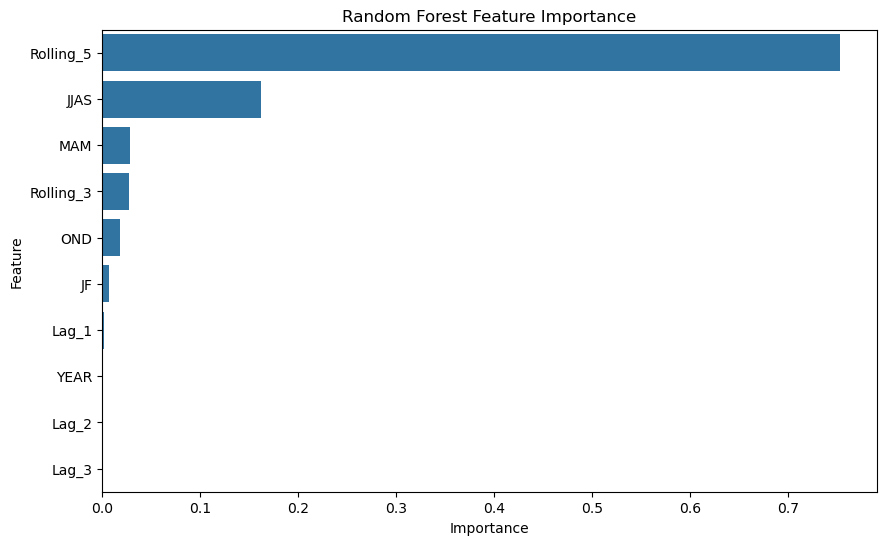

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.show()

In [37]:
#xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_pred_xgb = xgb_model.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_xgb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

r2 = r2_score(y_test, y_pred_xgb)

mape = np.mean(
    np.abs((y_test - y_pred_xgb) / y_test)
) * 100

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("MAPE :", mape)

MAE : 33.66764452643342
RMSE : 102.95932840475179
R² : 0.9872159002459393
MAPE : 2.2928152018882755


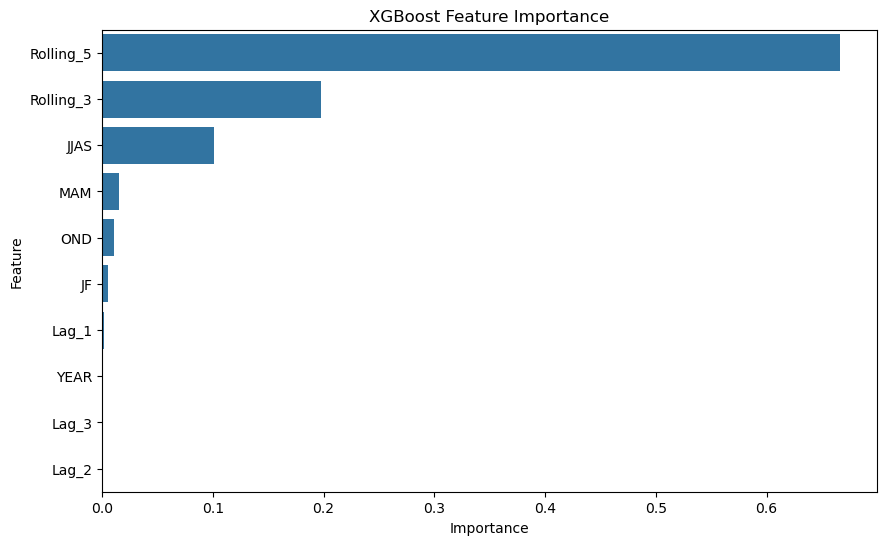

In [40]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")

plt.show()

In [41]:
features_forecast = [
    'YEAR',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_3',
    'Rolling_5'
]

X = df[features_forecast]
y = df['ANNUAL']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from xgboost import XGBRegressor

forecast_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

forecast_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
y_pred = forecast_model.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred)/y_test))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("MAPE :", mape)

MAE : 211.06127991237958
RMSE : 327.5785043170248
R² : 0.8705894926090965
MAPE : 16.46321672573728


In [46]:
#model comparison
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost Estimation', 'XGBoost Forecast'],
    'R2 Score': [0.9804, 0.9872, 0.8706],
    'MAPE (%)': [3.21, 2.29, 16.46]
})

comparison

,Model,R2 Score,MAPE (%)
0,Random Forest,0.9804,3.21
1,XGBoost Estimation,0.9872,2.29
2,XGBoost Forecast,0.8706,16.46


In [48]:
df['SUBDIVISION'].nunique()

36

In [50]:
df['SUBDIVISION'].unique()

array(['Andaman & Nicobar Islands', 'Arunachal Pradesh',
       'Assam & Meghalaya', 'Bihar', 'Chhattisgarh',
       'Coastal Andhra Pradesh', 'Coastal Karnataka',
       'East Madhya Pradesh', 'East Rajasthan', 'East Uttar Pradesh',
       'Gangetic West Bengal', 'Gujarat Region',
       'Haryana Delhi & Chandigarh', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Kerala', 'Konkan & Goa',
       'Lakshadweep', 'Madhya Maharashtra', 'Matathwada',
       'Naga Mani Mizo Tripura', 'North Interior Karnataka', 'Orissa',
       'Punjab', 'Rayalseema', 'Saurashtra & Kutch',
       'South Interior Karnataka', 'Sub Himalayan West Bengal & Sikkim',
       'Tamil Nadu', 'Telangana', 'Uttarakhand', 'Vidarbha',
       'West Madhya Pradesh', 'West Rajasthan', 'West Uttar Pradesh'],
      dtype=object)

In [49]:
#create forecast base
forecast_data = []

for subdivision in df['SUBDIVISION'].unique():

    sub_df = df[df['SUBDIVISION'] == subdivision].sort_values('YEAR')

    if len(sub_df) < 10:
        continue

    forecast_data.append({
        'Subdivision': subdivision,
        'Last_Year': sub_df['YEAR'].max(),
        'Last_Rainfall': sub_df['ANNUAL'].iloc[-1]
    })

forecast_base = pd.DataFrame(forecast_data)

forecast_base.head()

,Subdivision,Last_Year,Last_Rainfall
0,Andaman & Nicobar Islands,2017,2890.0
1,Arunachal Pradesh,2017,2745.3
2,Assam & Meghalaya,2017,2711.7
3,Bihar,2017,1112.0
4,Chhattisgarh,2017,1124.4


In [51]:
#Time-Series XGBoost Forecasting
features_forecast = [
    'YEAR',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_3',
    'Rolling_5'
]

X = df[features_forecast]
y = df['ANNUAL']

In [52]:
train_df = df[df['YEAR'] <= 2010]

test_df = df[df['YEAR'] > 2010]

X_train = train_df[features_forecast]
y_train = train_df['ANNUAL']

X_test = test_df[features_forecast]
y_test = test_df['ANNUAL']

In [53]:
from xgboost import XGBRegressor

ts_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

ts_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
y_pred = ts_model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred)/y_test))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("MAPE :", mape)

MAE : 260.95087563425153
RMSE : 369.55621629599915
R² : 0.809793752534133
MAPE : 25.011516305115993


In [ ]:
#While estimation models achieved very high accuracy using seasonal rainfall inputs, the time-series forecasting model provided a more realistic prediction scenario by using only historical rainfall information.

In [56]:
df[['SUBDIVISION','YEAR','ANNUAL']].tail(20)

,SUBDIVISION,YEAR,ANNUAL
1244,West Uttar Pradesh,1998,867.2
1245,West Uttar Pradesh,1999,786.4
1246,West Uttar Pradesh,2000,771.4
1247,West Uttar Pradesh,2001,661.7
1248,West Uttar Pradesh,2002,625.2
1249,West Uttar Pradesh,2003,1047.5
1250,West Uttar Pradesh,2004,642.3
1251,West Uttar Pradesh,2005,725.7
1252,West Uttar Pradesh,2006,529.3
1253,West Uttar Pradesh,2007,572.5


In [57]:
#crate forecast
forecast_results = []

for subdivision in df['SUBDIVISION'].unique():

    sub_df = df[df['SUBDIVISION'] == subdivision].sort_values('YEAR').copy()

    for year in range(2018, 2031):

        lag_1 = sub_df['ANNUAL'].iloc[-1]
        lag_2 = sub_df['ANNUAL'].iloc[-2]
        lag_3 = sub_df['ANNUAL'].iloc[-3]

        rolling_3 = sub_df['ANNUAL'].tail(3).mean()
        rolling_5 = sub_df['ANNUAL'].tail(5).mean()

        future_data = pd.DataFrame({
            'YEAR': [year],
            'Lag_1': [lag_1],
            'Lag_2': [lag_2],
            'Lag_3': [lag_3],
            'Rolling_3': [rolling_3],
            'Rolling_5': [rolling_5]
        })

        prediction = ts_model.predict(future_data)[0]

        forecast_results.append([
            subdivision,
            year,
            prediction
        ])

        new_row = pd.DataFrame({
            'YEAR': [year],
            'ANNUAL': [prediction]
        })

        sub_df = pd.concat([sub_df, new_row], ignore_index=True)

In [58]:
forecast_df = pd.DataFrame(
    forecast_results,
    columns=[
        'SUBDIVISION',
        'YEAR',
        'FORECAST_RAINFALL'
    ]
)

forecast_df.head()

,SUBDIVISION,YEAR,FORECAST_RAINFALL
0,Andaman & Nicobar Islands,2018,3026.937256
1,Andaman & Nicobar Islands,2019,3044.760498
2,Andaman & Nicobar Islands,2020,3094.262451
3,Andaman & Nicobar Islands,2021,3335.996582
4,Andaman & Nicobar Islands,2022,3121.244873


In [59]:
forecast_df.to_csv(
    "rainfall_forecast_2018_2030.csv",
    index=False
)

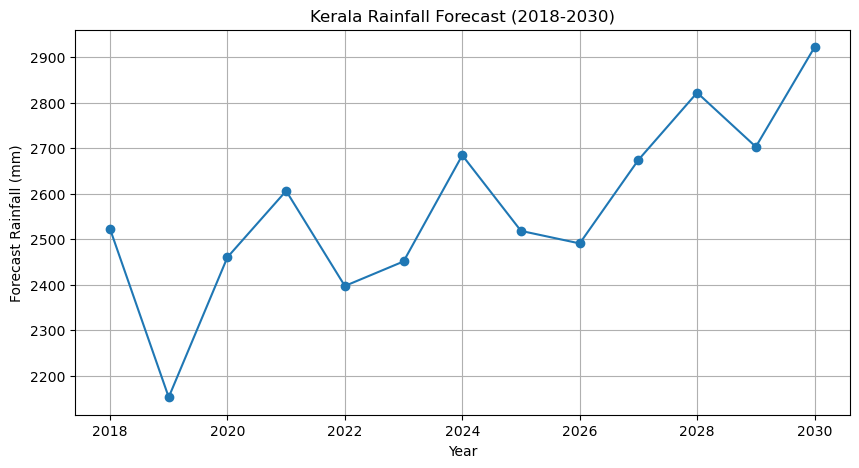

In [60]:
kerala = forecast_df[
    forecast_df['SUBDIVISION'] == 'Kerala'
]

plt.figure(figsize=(10,5))

plt.plot(
    kerala['YEAR'],
    kerala['FORECAST_RAINFALL'],
    marker='o'
)

plt.title("Kerala Rainfall Forecast (2018-2030)")
plt.xlabel("Year")
plt.ylabel("Forecast Rainfall (mm)")

plt.grid(True)

plt.show()

In [62]:
historical_stats = df.groupby('SUBDIVISION')['ANNUAL'].agg([
    'mean',
    'std'
]).reset_index()

historical_stats.head()

,SUBDIVISION,mean,std
0,Andaman & Nicobar Islands,2833.221451,527.529461
1,Arunachal Pradesh,3275.735073,1105.030745
2,Assam & Meghalaya,2574.183036,313.122932
3,Bihar,1196.920536,193.102131
4,Chhattisgarh,1373.244643,209.957007


In [64]:
forecast_alerts = forecast_df.merge(
    historical_stats,
    on='SUBDIVISION'
)

forecast_alerts.head()

,SUBDIVISION,YEAR,FORECAST_RAINFALL,mean,std
0,Andaman & Nicobar Islands,2018,3026.937256,2833.221451,527.529461
1,Andaman & Nicobar Islands,2019,3044.760498,2833.221451,527.529461
2,Andaman & Nicobar Islands,2020,3094.262451,2833.221451,527.529461
3,Andaman & Nicobar Islands,2021,3335.996582,2833.221451,527.529461
4,Andaman & Nicobar Islands,2022,3121.244873,2833.221451,527.529461


In [65]:
##create alert categories
def rainfall_alert(row):

    if row['FORECAST_RAINFALL'] < (row['mean'] - row['std']):
        return "Drought Alert"

    elif row['FORECAST_RAINFALL'] > (row['mean'] + row['std']):
        return "Heavy Rainfall Alert"

    else:
        return "Normal"

In [66]:
forecast_alerts['Alert'] = forecast_alerts.apply(
    rainfall_alert,
    axis=1
)

forecast_alerts.head()

,SUBDIVISION,YEAR,FORECAST_RAINFALL,mean,std,Alert
0,Andaman & Nicobar Islands,2018,3026.937256,2833.221451,527.529461,Normal
1,Andaman & Nicobar Islands,2019,3044.760498,2833.221451,527.529461,Normal
2,Andaman & Nicobar Islands,2020,3094.262451,2833.221451,527.529461,Normal
3,Andaman & Nicobar Islands,2021,3335.996582,2833.221451,527.529461,Normal
4,Andaman & Nicobar Islands,2022,3121.244873,2833.221451,527.529461,Normal


In [67]:
forecast_alerts['Alert'].value_counts()

Alert
Normal                  277
Heavy Rainfall Alert    121
Drought Alert            70
Name: count, dtype: int64

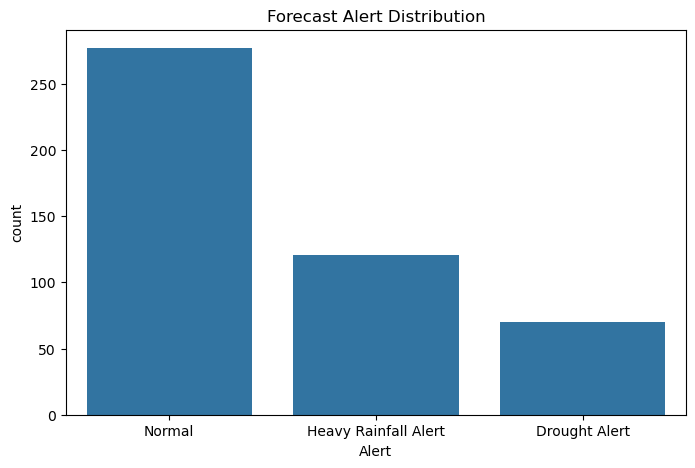

In [68]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=forecast_alerts,
    x='Alert'
)

plt.title("Forecast Alert Distribution")

plt.show()

In [70]:
#farmer advisory
def farmer_advisory(alert):

    if alert == "Drought Alert":
        return (
            "Use drought-resistant crops and "
            "implement water conservation practices."
        )

    elif alert == "Heavy Rainfall Alert":
        return (
            "Improve drainage systems and "
            "prepare flood protection measures."
        )

    else:
        return (
            "Suitable conditions for normal "
            "agricultural activities."
        )

In [71]:
forecast_alerts['Farmer_Advisory'] = (
    forecast_alerts['Alert']
    .apply(farmer_advisory)
)

forecast_alerts.head()

,SUBDIVISION,YEAR,FORECAST_RAINFALL,mean,std,Alert,Farmer_Advisory
0,Andaman & Nicobar Islands,2018,3026.937256,2833.221451,527.529461,Normal,Suitable conditions for normal agricultural ac...
1,Andaman & Nicobar Islands,2019,3044.760498,2833.221451,527.529461,Normal,Suitable conditions for normal agricultural ac...
2,Andaman & Nicobar Islands,2020,3094.262451,2833.221451,527.529461,Normal,Suitable conditions for normal agricultural ac...
3,Andaman & Nicobar Islands,2021,3335.996582,2833.221451,527.529461,Normal,Suitable conditions for normal agricultural ac...
4,Andaman & Nicobar Islands,2022,3121.244873,2833.221451,527.529461,Normal,Suitable conditions for normal agricultural ac...


In [72]:
forecast_alerts.to_csv(
    "Rainfall_Alerts_Advisory.csv",
    index=False
)

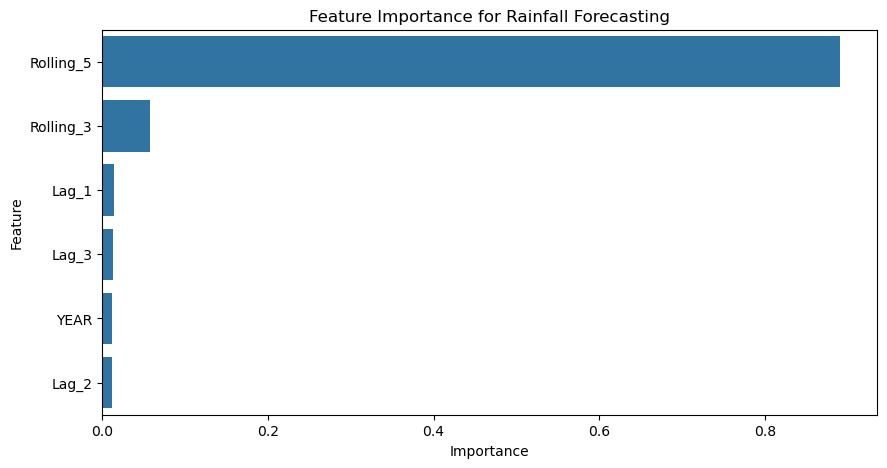

In [73]:
importance = pd.DataFrame({
    'Feature': features_forecast,
    'Importance': ts_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance for Rainfall Forecasting")

plt.show()

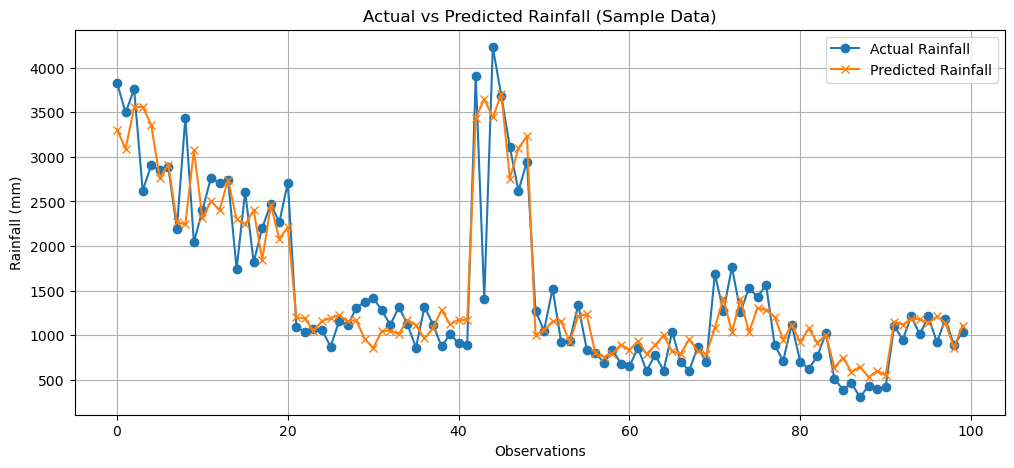

In [76]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label='Actual Rainfall',
    marker='o'
)

plt.plot(
    y_pred[:100],
    label='Predicted Rainfall',
    marker='x'
)

plt.title("Actual vs Predicted Rainfall (Sample Data)")
plt.xlabel("Observations")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True)

plt.show()